In [2]:
import os
import h5py
import numpy as np
import pandas as pd
from scipy import sparse
from matplotlib import pyplot as plt
from py_monocle import (
    learn_graph,
    order_cells,
    compute_cell_states,
    regression_analysis,
    differential_expression_genes,
)
import scanpy as sc

In [8]:
#FILE_NAME = "../data/pancreas.h5ad"
FILE_NAME = "../data/setty_bone_marrow.h5ad"
adata = sc.read(
    filename=FILE_NAME
)

In [ ]:
adata

In [9]:
import random
seed=42
random.seed(seed)
np.random.seed(seed)


In [10]:
tsne = adata.obsm["X_tsne"]
sc.pp.filter_genes(adata, min_counts=20)
sc.pp.normalize_total(adata)
sc.pp.log1p(adata)
sc.pp.highly_variable_genes(adata)

sc.tl.pca(adata)
sc.pp.neighbors(adata, n_neighbors=50, n_pcs=10)
sc.tl.diffmap(adata, n_comps=10)
sc.tl.umap(adata)

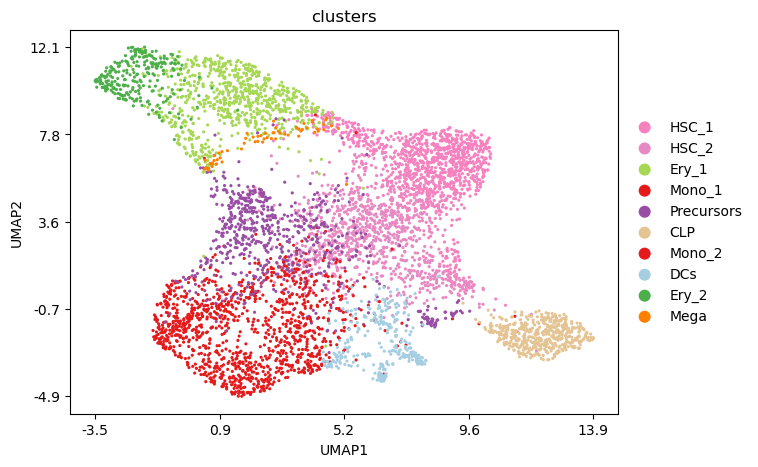

In [11]:
import matplotlib.pyplot as plt
import numpy as np

ax = sc.pl.scatter(adata, basis="umap", color="clusters", 
                   frameon=True, show=False)

# Get the coordinate range from the data
coords = adata.obsm["X_umap"]
x_ticks = np.linspace(coords[:, 0].min(), coords[:, 0].max(), 5)
y_ticks = np.linspace(coords[:, 1].min(), coords[:, 1].max(), 5)

ax.set_xticks(x_ticks)
ax.set_yticks(y_ticks)
ax.set_xticklabels([f"{x:.1f}" for x in x_ticks])
ax.set_yticklabels([f"{y:.1f}" for y in y_ticks])

plt.show()

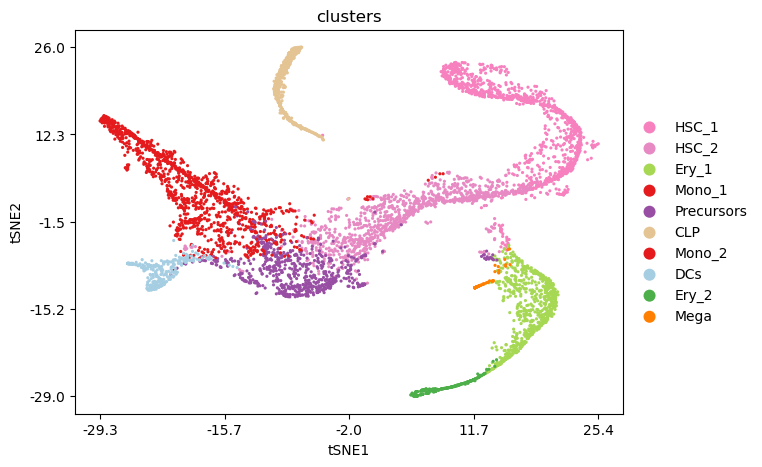

In [12]:
import matplotlib.pyplot as plt
import numpy as np

ax = sc.pl.scatter(adata, basis="tsne", color="clusters", 
                   frameon=True, show=False)

# Get the coordinate range from the data
coords = adata.obsm["X_tsne"]
x_ticks = np.linspace(coords[:, 0].min(), coords[:, 0].max(), 5)
y_ticks = np.linspace(coords[:, 1].min(), coords[:, 1].max(), 5)

ax.set_xticks(x_ticks)
ax.set_yticks(y_ticks)
ax.set_xticklabels([f"{x:.1f}" for x in x_ticks])
ax.set_yticklabels([f"{y:.1f}" for y in y_ticks])

plt.show()

In [15]:
# Work with boolean masks on the original array
mask_half    = tsne[:, 0] > tsne[:, 0].mean()
mask_quarter = mask_half & (tsne[:, 1] > tsne[:, 1].mean())

# argmax within the quarter, but mapped back to original indices
original_indices = np.where(mask_quarter)[0]
root_ixs = original_indices[tsne[mask_quarter, 1].argmax()]

adata.uns["iroot"] = root_ixs

print(root_ixs)
print(tsne[root_ixs])



5531
[ 9.7211828506 23.6046549287]


In [16]:
sc.pp.neighbors(adata, n_neighbors=50, use_rep='X_umap')
sc.tl.leiden(adata)
leiden = adata.obs["leiden"].to_numpy(dtype=int)

/var/folders/4k/lkwwfnw57332tg4t_n8tqy5m0000gn/T/ipykernel_12968/3124975804.py:2: FutureWarning: In the future, the default backend for leiden will be igraph instead of leidenalg.

 To achieve the future defaults please pass: flavor="igraph" and n_iterations=2.  directed must also be False to work with igraph's implementation.
  sc.tl.leiden(adata)


In [17]:
umap = adata.obsm["X_umap"]
projected_points, mst, centroids = learn_graph(matrix=umap, clusters=leiden)

In [18]:
pseudotime = order_cells(
    umap, centroids,
    mst=mst,
    projected_points=projected_points,
    root_cells=[root_ixs],
)


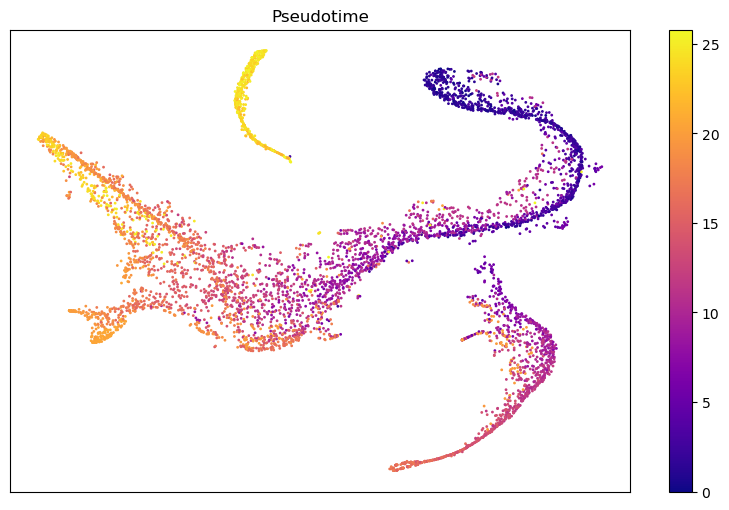

In [20]:
plt.figure(1, (10, 6))
plt.title("Pseudotime")
plt.scatter(tsne[:, 0], tsne[:, 1], c=pseudotime, s=1, cmap="plasma")
plt.xticks([])
plt.yticks([])
plt.colorbar()
plt.show()

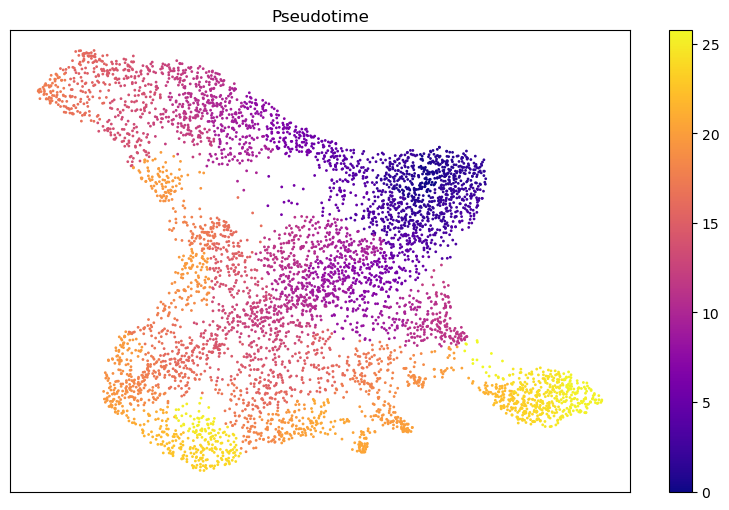

In [21]:
plt.figure(1, (10, 6))
plt.title("Pseudotime")
plt.scatter(umap[:, 0], umap[:, 1], c=pseudotime, s=1, cmap="plasma")
plt.xticks([])
plt.yticks([])
plt.colorbar()
plt.show()

In [35]:
FILE_NAME = "../data/setty_bone_marrow.h5ad"
adata = sc.read(
    filename=FILE_NAME
)

In [36]:
def preprocess_data(adata_subsampled):
    tsne = adata_subsampled.obsm["X_tsne"]
    sc.pp.filter_genes(adata_subsampled, min_counts=20)
    sc.pp.normalize_total(adata_subsampled)
    sc.pp.log1p(adata_subsampled)
    sc.pp.highly_variable_genes(adata_subsampled)

    sc.tl.pca(adata_subsampled, random_state=42)
    sc.pp.neighbors(adata_subsampled, n_neighbors=50, n_pcs=10, random_state=42)
    sc.tl.diffmap(adata_subsampled, n_comps=10)
    sc.tl.umap(adata_subsampled, random_state=42)
    return adata_subsampled, tsne

In [37]:
def monocle_pseudotime(adata, tsne):
    umap = adata.obsm["X_umap"]

    # Work with boolean masks on the original array
    mask_half    = tsne[:, 0] > tsne[:, 0].mean()
    mask_quarter = mask_half & (tsne[:, 1] > tsne[:, 1].mean())

    # argmax within the quarter, but mapped back to original indices
    original_indices = np.where(mask_quarter)[0]
    root_ixs = original_indices[tsne[mask_quarter, 1].argmax()]

    adata.uns["iroot"] = root_ixs

    sc.pp.neighbors(adata, n_neighbors=50, use_rep='X_umap')
    sc.tl.leiden(adata)
    leiden = adata.obs["leiden"].to_numpy(dtype=int)
    projected_points, mst, centroids = learn_graph(matrix=umap, clusters=leiden)
    pseudotime = order_cells(
    umap, centroids,
    mst=mst,
    projected_points=projected_points,
    root_cells=[root_ixs],
    )
    adata.obs["monocle"] = pseudotime

    return adata.obs["monocle"], root_ixs, umap

In [38]:
adata, tsne = preprocess_data(adata)
monocle_pseudotimes, root, umap = monocle_pseudotime(adata, tsne)


In [7]:
print(tsne[root])
print(umap[root])

[ 9.7211828506 23.6046549287]
[8.77758   6.6506324]


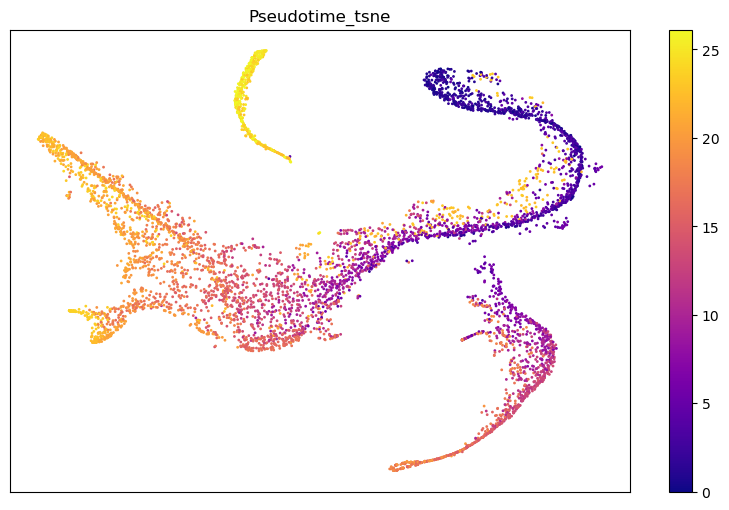

In [39]:
plt.figure(1, (10, 6))
plt.title("Pseudotime_tsne")
plt.scatter(tsne[:, 0], tsne[:, 1], c=monocle_pseudotimes, s=1, cmap="plasma")
plt.xticks([])
plt.yticks([])
plt.colorbar()
plt.show()

In [20]:
sc.tl.umap(adata, random_state=42)
umap = adata.obsm["X_umap"]

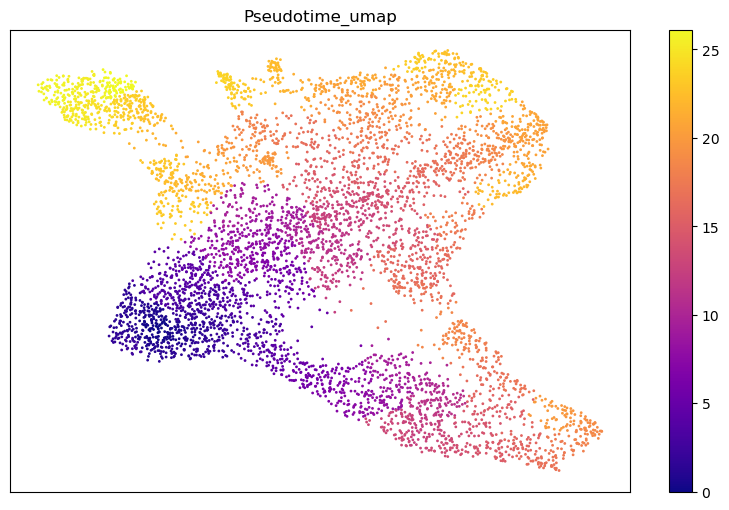

In [40]:
plt.figure(1, (10, 6))
plt.title("Pseudotime_umap")
plt.scatter(umap[:, 0], umap[:, 1], c=monocle_pseudotimes, s=1, cmap="plasma")
plt.xticks([])
plt.yticks([])
plt.colorbar()
plt.show()

In [22]:
FILE_NAME = "../data/setty_bone_marrow.h5ad"
adata = sc.read(
    filename=FILE_NAME
)

In [25]:

sc.tl.pca(adata, random_state=42)
sc.pp.neighbors(adata, n_neighbors=50, n_pcs=10, random_state=42)
sc.tl.umap(adata, random_state=42)

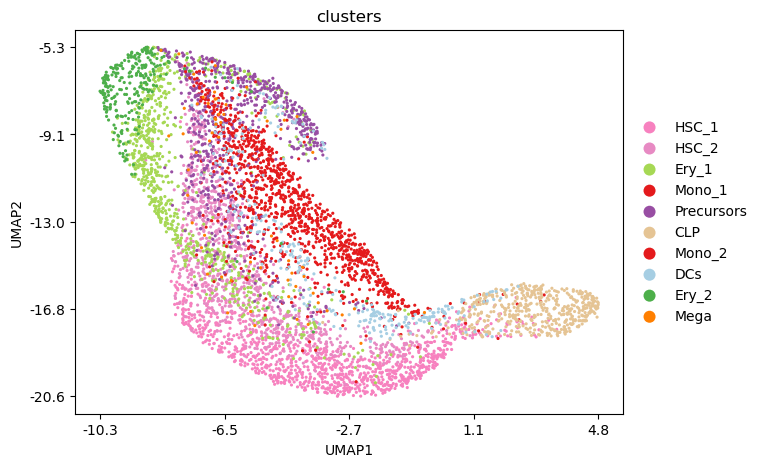

In [26]:
import matplotlib.pyplot as plt
import numpy as np

ax = sc.pl.scatter(adata, basis="umap", color="clusters", 
                   frameon=True, show=False)

# Get the coordinate range from the data
coords = adata.obsm["X_umap"]
x_ticks = np.linspace(coords[:, 0].min(), coords[:, 0].max(), 5)
y_ticks = np.linspace(coords[:, 1].min(), coords[:, 1].max(), 5)

ax.set_xticks(x_ticks)
ax.set_yticks(y_ticks)
ax.set_xticklabels([f"{x:.1f}" for x in x_ticks])
ax.set_yticklabels([f"{y:.1f}" for y in y_ticks])

plt.show()